In [1]:
import torch 
import os
import torch.optim
import torch.nn as nn
import torchvision.datasets as dset
from torch.utils.data import dataloader
from torchvision.transforms import transforms
import torchvision.utils as vutils
import numpy as np 
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from timeit import default_timer as timer
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)

2.10.0+cu128
True
12.8


In [2]:
#Custom anime datasetclass
from torch.utils.data import Dataset
from PIL import Image
import os 

class anime_dataset(Dataset):
    def __init__(self, root , transforms=None):
        self.root = root
        self.image = os.listdir(root)
        self.transforms = transforms

    def __len__(self):
        return(len(self.image))

    def __getitem__(self, idx):
       img_path = os.path.join(self.root, self.image[idx])
       img = Image.open(img_path).convert('RGB')
       if self.transforms:
           img = self.transforms(img)
       return img 

In [3]:
#transform

data_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),(0.5, 0.5, 0.5))
])

In [4]:
#dataste and dataloader
data_root = '/kaggle/input/datasets/splcher/animefacedataset/images'
anime_data = anime_dataset(root=data_root, transforms=data_transforms)

anime_dataloader = torch.utils.data.DataLoader(anime_data,
                                               batch_size=64,
                                               shuffle=True,
                                               pin_memory=True,
                                               drop_last=True)

print(f'Total Lenght of dataset:{len(anime_data)}')
print(f'Total lenght of dataloader:{len(anime_dataloader)} ')

Total Lenght of dataset:63565
Total lenght of dataloader:993 


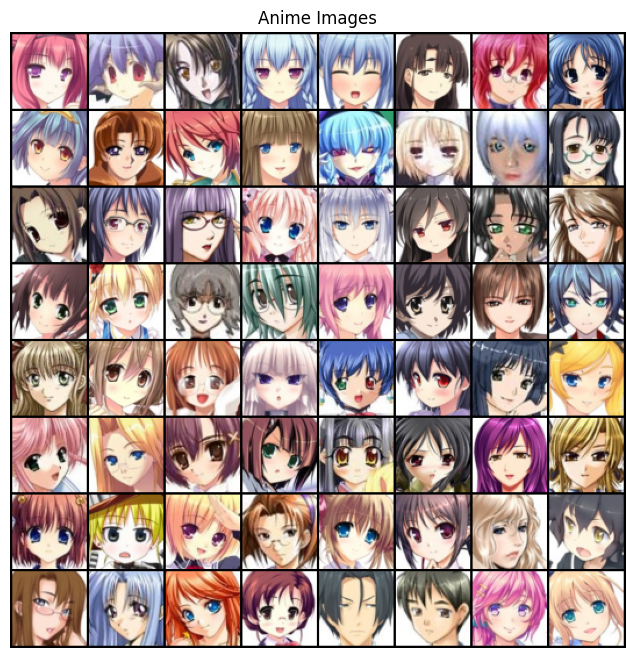

In [5]:
#visualizing dataset
batch = next(iter(anime_dataloader))
plt.figure(figsize=(8,8))
plt.axis('off')
plt.title('Anime Images')
plt.imshow(np.transpose(vutils.make_grid(batch[:64], padding=2, normalize=True).cpu(), (1,2,0)))
plt.show()


In [6]:
#variance schedule
T = 1000
beta_start = 1e-4
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end , steps=T)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

In [7]:
#forward pass 
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)

    sqrt_alphas_cumprod_t = torch.sqrt(alphas_cumprod[t]).view(-1, 1, 1, 1)
    sqrt_one_minus_alphas_cumprod_t = torch.sqrt(1. - alphas_cumprod[t]).view(-1,1,1,1)

    return sqrt_alphas_cumprod_t * x0 + sqrt_one_minus_alphas_cumprod_t*noise

In [8]:
#device 
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device 

'cuda'

In [9]:
alphas_cumprod = alphas_cumprod.to(device)

In [10]:
#SinusoidalPositionEmbeddings
import math
import torch.nn as nn 

class SinusoidalPositionEmbeddings(torch.nn.Module):
    def __init__(self, dim:int):
        super().__init__()
        assert dim % 2 == 0, "Embedding must divisble by 2"
        self.dim = dim 
    
    def forward(self, time_stamps: torch.Tensor) -> torch.Tensor :
        device = time_stamps.device
        half_dim = self.dim // 2
        scale = math.log(10000)/ (half_dim - 1)
        freqs= torch.exp(torch.arange(half_dim, dtype=torch.float32, device=device) * -scale)
        embeddings = time_stamps[:, None].float() * freqs[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings 
        

In [11]:
#time embedding 

class Time_embeddings(torch.nn.Module):
    def __init__(self, time_emb_dim: int, out_dim: int):
        super().__init__()
        self.sinusoidal_emb = SinusoidalPositionEmbeddings(time_emb_dim)

        self.mlp = nn.Sequential(
            nn.Linear(time_emb_dim, out_dim),
            nn.SiLU(),
            nn.Linear(out_dim, out_dim)
        )
    def forward (self, time_steps: torch.Tensor) -> torch.Tensor :
        raw_emb = self.sinusoidal_emb(time_steps)
        return self.mlp(raw_emb)

In [12]:
#Resblock 

class ResBlock(torch.nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_channels)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.act = nn.SiLU()
        self.time_mlp = nn.Linear(time_emb_dim, out_channels)
        #Matches in_channels and out_channels for skip connections 
        self.residual_conv = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, time_emb):
        h = self.norm1(self.conv1(x))
        h = self.act(h)
        # inject time embedding — shape (B, out_channels) → (B, out_channels, 1, 1)
        time_proj = self.act(self.time_mlp(time_emb))[:, :, None, None]
        h = h + time_proj 
        h = self.norm2(self.conv2(h))
        h = self.act(h)
        return h + self.residual_conv(x)


In [13]:
#downsample and upsample 

class Down_sample(torch.nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 4, stride=2, padding=1)
    def forward(self, x):
        return self.conv(x)

class Up_sample(torch.nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.ConvTranspose2d(channels, channels, 4, stride=2, padding=1)
    def forward(self, x):
        return self.conv(x)

In [14]:
#Full Unet class 

class Unet(nn.Module):
    def __init__(self, in_channels=3, time_emb_dim=128):
        super().__init__()
        # time embedding outputs 256-dim vector
        self.time_embeddings = Time_embeddings(time_emb_dim, out_dim=256)

        self.inc = nn.Conv2d(in_channels, 64, 3, padding=1)

        # Encoder
        self.down1 = ResBlock(64, 128, time_emb_dim=256)
        self.down_sample1 = Down_sample(128)

        self.down2 = ResBlock(128, 256, time_emb_dim=256)
        self.down_sample2 = Down_sample(256)

        # Bottleneck
        self.bot1 = ResBlock(256, 256, time_emb_dim=256)
        self.bot2 = ResBlock(256, 256, time_emb_dim=256)

        # Decoder (input channels doubled due to skip connection concat)
        self.up_sample1 = Up_sample(256)
        self.up1 = ResBlock(512, 128, time_emb_dim=256)   # 256 + 256 = 512

        self.up_sample2 = Up_sample(128)
        self.up2 = ResBlock(256, 64, time_emb_dim=256)    # 128 + 128 = 256

        self.outc = nn.Conv2d(64, in_channels, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_embeddings(t)      # (B,) → (B, 256)

        # Encoder
        x1 = self.inc(x)                    # (B, 64, 64, 64)
        x2 = self.down1(x1, t_emb)          # (B, 128, 64, 64)
        x3 = self.down_sample1(x2)          # (B, 128, 32, 32)
        x4 = self.down2(x3, t_emb)          # (B, 256, 32, 32)
        x5 = self.down_sample2(x4)          # (B, 256, 16, 16)

        # Bottleneck
        x5 = self.bot1(x5, t_emb)           # (B, 256, 16, 16)
        x5 = self.bot2(x5, t_emb)           # (B, 256, 16, 16)

        # Decoder
        x6 = self.up_sample1(x5)            # (B, 256, 32, 32)
        x6 = torch.cat([x6, x4], dim=1)     # (B, 512, 32, 32) — skip from x4
        x6 = self.up1(x6, t_emb)            # (B, 128, 32, 32)

        x7 = self.up_sample2(x6)            # (B, 128, 64, 64)
        x7 = torch.cat([x7, x2], dim=1)     # (B, 256, 64, 64) — skip from x2
        x7 = self.up2(x7, t_emb)            # (B, 64, 64, 64)

        return self.outc(x7)                 # (B, 3, 64, 64)
        

In [15]:
from torchinfo import summary

model = Unet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()
summary(model)

Layer (type:depth-idx)                        Param #
Unet                                          --
├─Time_embeddings: 1-1                        --
│    └─SinusoidalPositionEmbeddings: 2-1      --
│    └─Sequential: 2-2                        --
│    │    └─Linear: 3-1                       33,024
│    │    └─SiLU: 3-2                         --
│    │    └─Linear: 3-3                       65,792
├─Conv2d: 1-2                                 1,792
├─ResBlock: 1-3                               --
│    └─Conv2d: 2-3                            73,856
│    └─Conv2d: 2-4                            147,584
│    └─GroupNorm: 2-5                         256
│    └─GroupNorm: 2-6                         256
│    └─SiLU: 2-7                              --
│    └─Linear: 2-8                            32,896
│    └─Conv2d: 2-9                            8,320
├─Down_sample: 1-4                            --
│    └─Conv2d: 2-10                           262,272
├─ResBlock: 1-5               

In [16]:
#Function to move optimizer state and weights to device 
def optimizer_to_device(optimizer:torch.optim.Optimizer, device:torch.device):
    for state in optimizer.state.values():
        for k, v in state.items():
            if isinstance( v, torch.Tensor):
                state[k] = v.to(device)

In [17]:
#loading checkpiont 

checkpoint = torch.load('/kaggle/input/models/adityachaubeycode/ddpm/pytorch/default/1/best_checkpoint (1).pth', map_location=device)
print(checkpoint.keys())        
print(checkpoint['epoch'])      
print(checkpoint['loss'])       

#loading state_dict
model.load_state_dict(checkpoint['model_state_dict'])

#loading optimizer state dict 
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
optimizer_to_device(optimizer=optimizer, device=device)

start_epoch = 0
start_epoch = checkpoint['epoch'] +1
best_loss = checkpoint['loss']


dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'loss'])
9
0.025404917880937773


In [18]:
#Total time
def total_train_time(start:float, end:float, device:torch.device):
    total_time = end - start
    min = int(total_time //  60)
    sec = total_time%60
    print(f" Total time spend on device:{device} is {min}minutes and {sec:.2f}seconds")
    return total_time

In [19]:
torch.cuda.empty_cache()
print(f'GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB')
print(f'GPU memory reserved: {torch.cuda.memory_reserved()/1e9:.2f} GB')

GPU memory allocated: 0.12 GB
GPU memory reserved: 0.13 GB


In [20]:
# confirm these are all set before starting
print(next(model.parameters()).device)  # should be cuda
print(alphas_cumprod.device)            # should be cuda, if not: alphas_cumprod = alphas_cumprod.to(device)
print(len(anime_dataloader))            # sanity check dataloader works

cuda:0
cuda:0
993


In [21]:
#Full training loop '

from torch.cuda.amp import GradScaler, autocast 

scaler = torch.amp.GradScaler('cuda')
epochs = 10
start_epoch = checkpoint['epoch'] +1
best_loss = checkpoint['loss']
loss_history=[]
start_time = timer()

for epoch in tqdm(range(start_epoch, start_epoch + epochs)):
    print(f'{epoch+1}/{epochs}\n-----')
    model.train()
    train_loss = 0 

    for batch_idx,img in enumerate(anime_dataloader):
        
        img = img.to(device)
        t = torch.randint(0, T, (img.shape[0],), device=device)
        noise = torch.randn_like(img).to(device)
        xt = q_sample(x0=img, t=t, noise=noise)
        
        with torch.autocast('cuda'):
            output = model(xt, t)
            loss = loss_fn(output, noise)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        train_loss += loss.item()
        
    train_loss = train_loss / len(anime_dataloader)
    loss_history.append(train_loss)
    print(f' Avg loss :{train_loss:.4f}')
    
    if train_loss < best_loss:
        best_loss = train_loss
        torch.save({
            'epoch':epoch+1,
            'model_state_dict':model.state_dict(),
            'optimizer_state_dict':optimizer.state_dict(),
            'loss':best_loss,
        }, '/kaggle/working/best_checkpoint2.pth')
        print(f' Model saved at epoch :{epoch} | Current best loss:{best_loss:.4f}')

end_time = timer()
print_total_time = total_train_time(start=start_time, end=end_time, device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

11/10
-----
 Avg loss :0.0256
12/10
-----
 Avg loss :0.0253
 Model saved at epoch :11 | Current best loss:0.0253
13/10
-----
 Avg loss :0.0251
 Model saved at epoch :12 | Current best loss:0.0251
14/10
-----
 Avg loss :0.0251
15/10
-----
 Avg loss :0.0254
16/10
-----
 Avg loss :0.0249
 Model saved at epoch :15 | Current best loss:0.0249
17/10
-----
 Avg loss :0.0250
18/10
-----
 Avg loss :0.0247
 Model saved at epoch :17 | Current best loss:0.0247
19/10
-----
 Avg loss :0.0249
20/10
-----
 Avg loss :0.0245
 Model saved at epoch :19 | Current best loss:0.0245
 Total time spend on device:cuda is 56minutes and 48.30seconds


In [25]:
#Sampling loop 
sqrt_recip_alphas = torch.sqrt(1.0 / alphas).to(device)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod).to(device)
posterior_variance = betas.to(device)

@torch.no_grad()
def sample(model , image_size, batch_size=16, colour_channels=3):

    model.eval()
    img = torch.randn(batch_size, colour_channels, image_size, image_size).to(device)

    for t_step in reversed(range(0, T)):
        t_tensor = torch.full((batch_size,), t_step, dtype=torch.long, device=device)
        pred_noise = model(img, t_tensor)
        img = sqrt_recip_alphas[t_step] * (
            img - (betas[t_step] / sqrt_one_minus_alphas_cumprod[t_step]) * pred_noise
        )
        if t_step > 0:
            z = torch.randn_like(img)
            img = img + torch.sqrt(posterior_variance[t_step]) * z

    return img 

<function matplotlib.pyplot.show(close=None, block=None)>

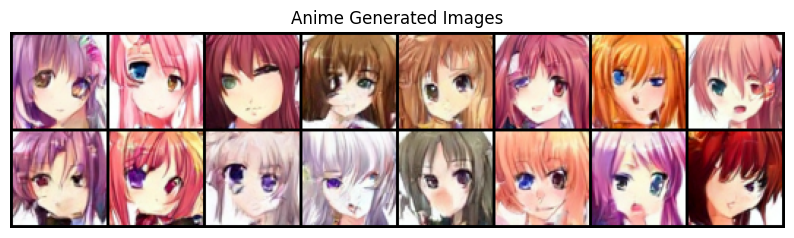

In [23]:
#Images generated by the model 

generate = sample(model , image_size=64, batch_size=16)
generate = (generate.clamp(-1,1) +1)/2

plt.figure(figsize=(10,10))
plt.axis('off')
plt.title('Anime Generated Images')
plt.imshow(np.transpose(vutils.make_grid(generate.cpu(), padding=2, normalize=True).numpy(), (1,2,0)))
plt.show

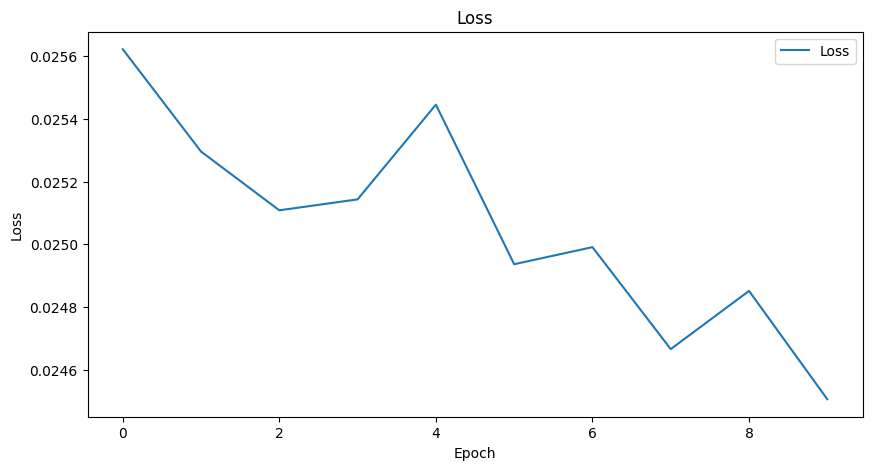

In [26]:
plt.figure(figsize=(10,5))
plt.title('Loss')
plt.plot(loss_history,label='Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()